text: hidcptqmerifcusymaqddcomolsujibeptsmycmqsrwgrcmywshgnfpjhc-c
meta: {'fs_native': 6, 'fs_used': 12, 'use_hd': True, 'allowed': (224, 224), 'pad': 0}


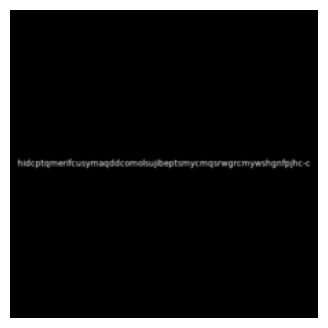

FOUND fs_native==8? True
example length: 38 glyph: a
text: aaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaa
meta: {'fs_native': 8, 'fs_used': 18, 'use_hd': True, 'allowed': (224, 224), 'pad': 0}


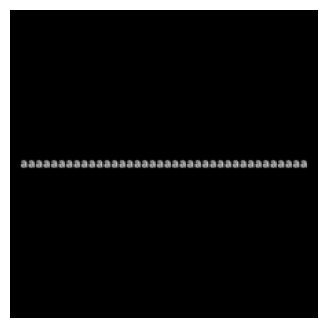

In [16]:
import unicodedata
from functools import lru_cache
from matplotlib import font_manager
from PIL import Image, ImageDraw, ImageFont
import matplotlib.pyplot as plt

# =========================
# Font caching (same idea)
# =========================
@lru_cache(maxsize=1)
def _get_font_path() -> str:
    return font_manager.findfont("DejaVu Sans", fallback_to_default=True)

@lru_cache(maxsize=2048)
def _get_font(font_size: int) -> ImageFont.FreeTypeFont:
    try:
        return ImageFont.truetype(_get_font_path(), int(font_size))
    except Exception:
        return ImageFont.load_default()

def _measure_text(draw: ImageDraw.ImageDraw, text: str, font: ImageFont.FreeTypeFont):
    x0, y0, x1, y1 = draw.textbbox((0, 0), text, font=font)
    return (x1 - x0), (y1 - y0), x0, y0

def _max_fitting_font_size(
    draw: ImageDraw.ImageDraw,
    text: str,
    allowed_w: int,
    allowed_h: int,
    base_font_size: int,
    min_font_size: int,
    max_font_cap: int,
):
    min_fs = max(1, int(min_font_size))
    cap_fs = max(min_fs, int(max_font_cap))
    base_fs = max(min_fs, min(cap_fs, int(base_font_size)))

    font0 = _get_font(base_fs)
    w0, h0, _, _ = _measure_text(draw, text, font0)
    if w0 <= 0 or h0 <= 0:
        font = _get_font(min_fs)
        w, h, x0, y0 = _measure_text(draw, text, font)
        return min_fs, w, h, x0, y0

    # IMPORTANT: allow scale > 1 (maximize)
    scale = min(allowed_w / w0, allowed_h / h0)
    est = int(base_fs * scale)
    est = max(min_fs, min(cap_fs, est))

    def fits(fs: int) -> bool:
        font = _get_font(fs)
        w, h, _, _ = _measure_text(draw, text, font)
        return (w <= allowed_w) and (h <= allowed_h)

    fs = est
    while fs > min_fs and not fits(fs):
        fs -= 1

    if fs == min_fs and not fits(fs):
        font = _get_font(min_fs)
        w, h, x0, y0 = _measure_text(draw, text, font)
        return min_fs, w, h, x0, y0

    lo = fs
    hi = min(cap_fs, max(lo + 1, lo))
    while hi < cap_fs and fits(hi):
        lo = hi
        hi = min(cap_fs, hi * 2)

    if fits(hi):
        lo = hi
        font = _get_font(lo)
        w, h, x0, y0 = _measure_text(draw, text, font)
        return lo, w, h, x0, y0

    low, high = lo, hi  # low fits, high does NOT fit
    while low + 1 < high:
        mid = (low + high) // 2
        if fits(mid):
            low = mid
        else:
            high = mid

    font = _get_font(low)
    w, h, x0, y0 = _measure_text(draw, text, font)
    return low, w, h, x0, y0

def generate_glyph_image(
    text: str,
    image_size=(224, 224),
    pad: int = 0,              # default per your requirement
    min_font_size: int = 1,
    base_font_size: int = 120,
    max_font_cap: int = 1024,
    hd_enabled: bool = True,   # default ON
    hd_threshold: int = 8,
    hd_scale: int = 2,
):
    text = unicodedata.normalize("NFC", str(text))
    W, H = int(image_size[0]), int(image_size[1])
    pad = int(pad)
    allowed_w = max(1, W - 2 * pad)
    allowed_h = max(1, H - 2 * pad)

    # Native best font size (decides HD trigger)
    tmp = Image.new("RGB", (W, H), (0, 0, 0))
    tmp_draw = ImageDraw.Draw(tmp)
    fs_native, _, _, _, _ = _max_fitting_font_size(
        tmp_draw, text, allowed_w, allowed_h, base_font_size, min_font_size, max_font_cap
    )

    use_hd = bool(hd_enabled and (hd_scale >= 2) and (fs_native <= int(hd_threshold)))

    if not use_hd:
        img = Image.new("RGB", (W, H), (0, 0, 0))
        draw = ImageDraw.Draw(img)
        fs, w, h, x0, y0 = _max_fitting_font_size(
            draw, text, allowed_w, allowed_h, base_font_size, min_font_size, max_font_cap
        )
        x = (W - w) // 2 - x0
        y = (H - h) // 2 - y0
        draw.text((x, y), text, font=_get_font(fs), fill=(255, 255, 255))
        return img, {"fs_native": fs_native, "fs_used": fs, "use_hd": False, "allowed": (allowed_w, allowed_h), "pad": pad}

    # HD path: render at 2x and downsample back to 224
    S = int(hd_scale)
    WR, HR = W * S, H * S
    pad_r = pad * S
    allowed_wr = max(1, WR - 2 * pad_r)
    allowed_hr = max(1, HR - 2 * pad_r)

    img_r = Image.new("RGB", (WR, HR), (0, 0, 0))
    draw_r = ImageDraw.Draw(img_r)
    fs_r, w_r, h_r, x0_r, y0_r = _max_fitting_font_size(
        draw_r, text, allowed_wr, allowed_hr, base_font_size * S, max(1, min_font_size * S), max_font_cap * S
    )
    x_r = (WR - w_r) // 2 - x0_r
    y_r = (HR - h_r) // 2 - y0_r
    draw_r.text((x_r, y_r), text, font=_get_font(fs_r), fill=(255, 255, 255))

    img = img_r.resize((W, H), resample=Image.Resampling.BILINEAR)
    return img, {"fs_native": fs_native, "fs_used": fs_r, "use_hd": True, "allowed": (allowed_w, allowed_h), "pad": pad}

def show(text, **kwargs):
    img, meta = generate_glyph_image(text, **kwargs)
    print("text:", text)
    print("meta:", meta)
    plt.figure(figsize=(4,4))
    plt.imshow(img)
    plt.axis("off")
    plt.show()

# =========================
# 1) Show your long string
# =========================
LONG = "hidcptqmerifcusymaqddcomolsujibeptsmycmqsrwgrcmywshgnfpjhc-c"
show(LONG, pad=0, hd_enabled=True, hd_threshold=8, hd_scale=2)

# =========================
# 2) Auto-find a string that yields fs_native == 8
#    (so you can confirm the threshold behavior)
# =========================
def fs_native_only(text, pad=0, base_font_size=120, min_font_size=1, max_font_cap=1024):
    text = unicodedata.normalize("NFC", str(text))
    W = H = 224
    allowed = W - 2*pad
    tmp = Image.new("RGB", (W, H), (0, 0, 0))
    d = ImageDraw.Draw(tmp)
    fs, *_ = _max_fitting_font_size(d, text, allowed, allowed, base_font_size, min_font_size, max_font_cap)
    return fs

target = 8
found = None

# try some common glyphs; widths differ, so this finds something quickly
glyphs = ["a", "m", "w", "0", "-", "x"]
for g in glyphs:
    for L in range(1, 400):
        s = g * L
        if fs_native_only(s, pad=0) == target:
            found = s
            break
    if found:
        break

print("FOUND fs_native==8?", found is not None)
if found:
    print("example length:", len(found), "glyph:", found[0])
    show(found, pad=0, hd_enabled=True, hd_threshold=8, hd_scale=2)

Detected fonts:
DejaVu          -> /Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/matplotlib/mpl-data/fonts/ttf/DejaVuSans.ttf
Pacifico        -> /Users/a../Downloads/Pacifico-Regular.ttf
SourceCodePro   -> /Users/a../Downloads/SourceCodePro.ttf
{'font': 'DejaVu', 'fs_used': 12, 'use_hd': True}
size: (224, 224)


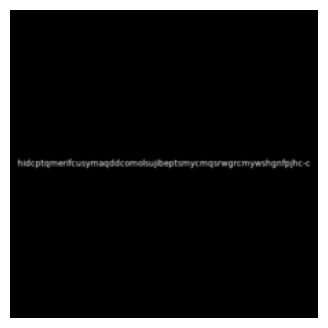

{'font': 'Pacifico', 'fs_used': 15, 'use_hd': True}
size: (224, 224)


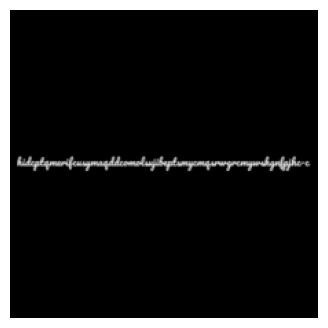

{'font': 'SourceCodePro', 'fs_used': 12, 'use_hd': True}
size: (224, 224)


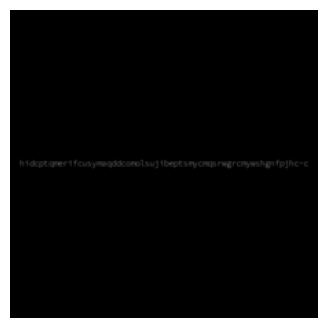

In [24]:
from pathlib import Path
import unicodedata
from functools import lru_cache

from matplotlib import font_manager
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw, ImageFont


# ==========================================================
# Locate fonts (Notebook-safe)
# ==========================================================
HERE = Path(".").resolve()

def _find_font_file(patterns):
    for pat in patterns:
        hits = sorted(HERE.glob(pat))
        if hits:
            return str(hits[0])
    return None

FONT_PATHS = {
    "DejaVu": font_manager.findfont("DejaVu Sans", fallback_to_default=True),
    "Pacifico": _find_font_file(["pacifico*.ttf", "Pacifico*.ttf"]),
    "SourceCodePro": _find_font_file(["SourceCodePro*.ttf", "sourcecodepro*.ttf"]),
}

print("Detected fonts:")
for k, v in FONT_PATHS.items():
    print(f"{k:15s} -> {v}")

# ==========================================================
# Font cache (now keyed by path + size)
# ==========================================================
@lru_cache(maxsize=4096)
def _get_font(font_path: str, font_size: int):
    return ImageFont.truetype(font_path, int(font_size))

def _measure_text(draw, text, font):
    x0, y0, x1, y1 = draw.textbbox((0, 0), text, font=font)
    return (x1 - x0), (y1 - y0), x0, y0


# ==========================================================
# MAX FIT (UNCHANGED LOGIC)
# ==========================================================
def _max_fitting_font_size(
    draw,
    text,
    allowed_w,
    allowed_h,
    base_font_size,
    min_font_size,
    max_font_cap,
    font_path,
):
    min_fs = max(1, int(min_font_size))
    cap_fs = max(min_fs, int(max_font_cap))
    base_fs = max(min_fs, min(cap_fs, int(base_font_size)))

    font0 = _get_font(font_path, base_fs)
    w0, h0, _, _ = _measure_text(draw, text, font0)

    if w0 <= 0 or h0 <= 0:
        font = _get_font(font_path, min_fs)
        w, h, x0, y0 = _measure_text(draw, text, font)
        return min_fs, w, h, x0, y0

    scale = min(allowed_w / w0, allowed_h / h0)
    est = int(base_fs * scale)
    est = max(min_fs, min(cap_fs, est))

    def fits(fs):
        font = _get_font(font_path, fs)
        w, h, _, _ = _measure_text(draw, text, font)
        return (w <= allowed_w) and (h <= allowed_h)

    fs = est
    while fs > min_fs and not fits(fs):
        fs -= 1

    lo = fs
    hi = min(cap_fs, max(lo + 1, lo))

    while hi < cap_fs and fits(hi):
        lo = hi
        hi = min(cap_fs, hi * 2)

    if fits(hi):
        lo = hi
        font = _get_font(font_path, lo)
        w, h, x0, y0 = _measure_text(draw, text, font)
        return lo, w, h, x0, y0

    low, high = lo, hi
    while low + 1 < high:
        mid = (low + high) // 2
        if fits(mid):
            low = mid
        else:
            high = mid

    font = _get_font(font_path, low)
    w, h, x0, y0 = _measure_text(draw, text, font)
    return low, w, h, x0, y0


# ==========================================================
# 224x224 GENERATOR (MULTI-FONT)
# ==========================================================
def generate_glyph_image(
    text,
    font_name="DejaVu",
    image_size=(224, 224),
    pad=0,
    min_font_size=1,
    base_font_size=120,
    max_font_cap=1024,
    hd_enabled=True,
    hd_threshold=8,
    hd_scale=2,
):
    text = unicodedata.normalize("NFC", str(text))
    font_path = FONT_PATHS[font_name]

    if font_path is None:
        raise ValueError(f"Font {font_name} not found.")

    W, H = image_size
    allowed_w = max(1, W - 2 * pad)
    allowed_h = max(1, H - 2 * pad)

    tmp = Image.new("RGB", (W, H), (0, 0, 0))
    tmp_draw = ImageDraw.Draw(tmp)

    fs_native, _, _, _, _ = _max_fitting_font_size(
        tmp_draw, text, allowed_w, allowed_h,
        base_font_size, min_font_size, max_font_cap,
        font_path,
    )

    use_hd = bool(hd_enabled and hd_scale >= 2 and fs_native <= hd_threshold)

    if not use_hd:
        img = Image.new("RGB", (W, H), (0, 0, 0))
        draw = ImageDraw.Draw(img)

        fs, w, h, x0, y0 = _max_fitting_font_size(
            draw, text, allowed_w, allowed_h,
            base_font_size, min_font_size, max_font_cap,
            font_path,
        )

        x = (W - w) // 2 - x0
        y = (H - h) // 2 - y0

        draw.text((x, y), text, font=_get_font(font_path, fs), fill=(255, 255, 255))
        return img, {"font": font_name, "fs_used": fs, "use_hd": False}

    # HD path
    S = hd_scale
    WR, HR = W * S, H * S
    allowed_wr = WR - 2 * pad * S
    allowed_hr = HR - 2 * pad * S

    img_r = Image.new("RGB", (WR, HR), (0, 0, 0))
    draw_r = ImageDraw.Draw(img_r)

    fs_r, w_r, h_r, x0_r, y0_r = _max_fitting_font_size(
        draw_r, text, allowed_wr, allowed_hr,
        base_font_size * S,
        min_font_size * S,
        max_font_cap * S,
        font_path,
    )

    x_r = (WR - w_r) // 2 - x0_r
    y_r = (HR - h_r) // 2 - y0_r

    draw_r.text((x_r, y_r), text, font=_get_font(font_path, fs_r), fill=(255, 255, 255))

    img = img_r.resize((W, H), resample=Image.Resampling.BILINEAR)
    return img, {"font": font_name, "fs_used": fs_r, "use_hd": True}


# ==========================================================
# SHOW HELPER
# ==========================================================
def show(text, font_name):
    img, meta = generate_glyph_image(text, font_name=font_name)
    print(meta)
    print("size:", img.size)
    plt.figure(figsize=(4,4))
    plt.imshow(img)
    plt.axis("off")
    plt.show()


# ==========================================================
# TEST
# ==========================================================
LONG = "hidcptqmerifcusymaqddcomolsujibeptsmycmqsrwgrcmywshgnfpjhc-c"

for f in ["DejaVu", "Pacifico", "SourceCodePro"]:
    show(LONG, f)

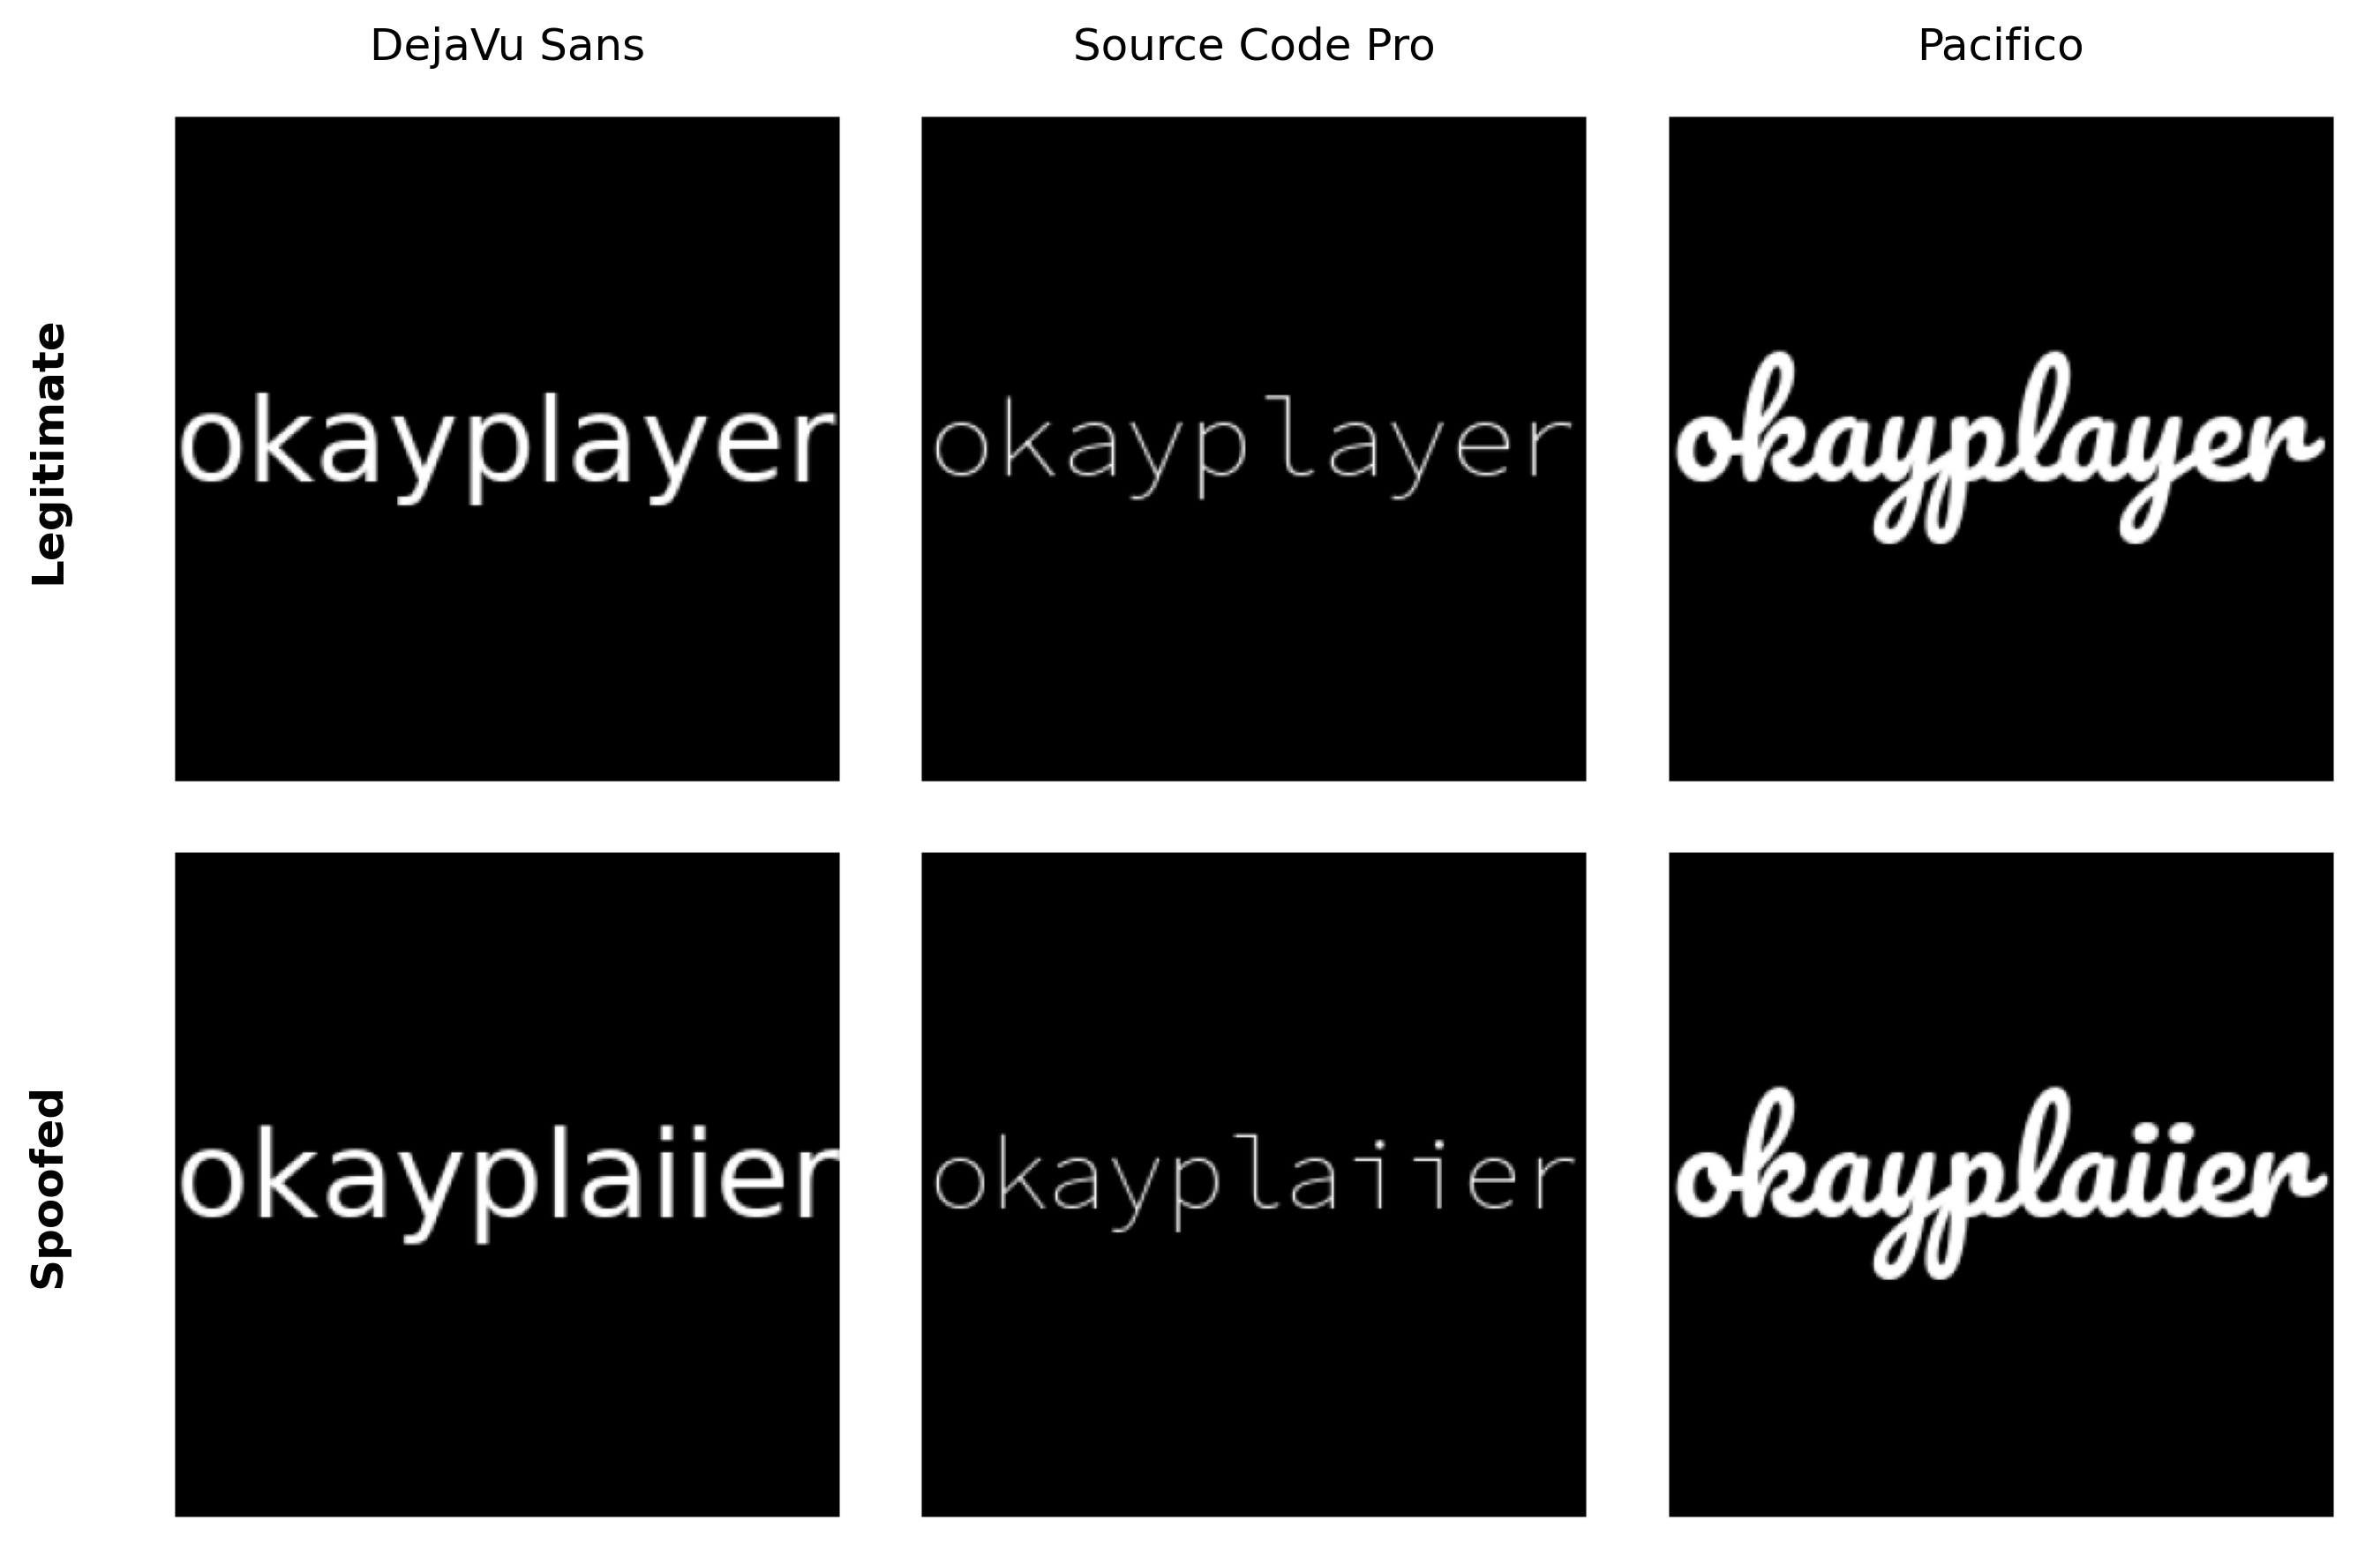

In [25]:
import matplotlib.pyplot as plt
from PIL import Image

# ---- Load images ----
img_paths = [
    "deja2.png",       # Row 1 Col 1
    "scp2.png",        # Row 1 Col 2
    "pacifico2.png",   # Row 1 Col 3
    "deja1.png",       # Row 2 Col 1
    "scp1.png",        # Row 2 Col 2
    "pacifico1.png",   # Row 2 Col 3
]

images = [Image.open(p) for p in img_paths]

# ---- Create figure ----
fig, axes = plt.subplots(
    nrows=2,
    ncols=3,
    figsize=(9, 6),  # good aspect for paper
    dpi=300
)

# ---- Plot images ----
for ax, img in zip(axes.flat, images):
    ax.imshow(img)
    ax.axis("off")

# ---- Column titles ----
col_titles = ["DejaVu Sans", "Source Code Pro", "Pacifico"]
for i, title in enumerate(col_titles):
    axes[0, i].set_title(title, fontsize=12, pad=10)

# ---- Row labels ----
row_labels = ["Legitimate", "Spoofed"]
for i, label in enumerate(row_labels):
    axes[i, 0].annotate(
        label,
        xy=(-0.15, 0.5),
        xycoords="axes fraction",
        rotation=90,
        va="center",
        ha="center",
        fontsize=12,
        fontweight="bold"
    )

plt.tight_layout()

# ---- Save outputs ----
plt.savefig("font_comparison_figure.pdf", bbox_inches="tight")
plt.savefig("font_comparison_figure.png", bbox_inches="tight", dpi=300)

plt.show()